##**Base Line Model Implementation Overview- VSDR**

This implementation adapts the Very Deep Super-Resolution (VDSR) network proposed by Kim et al. for our specific super-resolution needs. While the original paper demonstrated state-of-the-art results using 291 training images, we establish a baseline with just 50 images to validate the approach before full-scale deployment.

## Key Components from the Original Paper

The VDSR architecture introduces several innovations we've implemented:

1. **Very Deep Network Structure**  
   - 20-layer convolutional network (vs 3 layers in previous SRCNN)
   - All layers use 3×3 filters with 64 channels (except final layer)
   - Receptive field of 41×41 pixels (vs 13×13 in SRCNN)

2. **Residual Learning**  
   - Predicts only the difference (residual) between HR and LR images
   - Final output: HR = LR + predicted residual
   - Enables faster convergence and higher learning rates

3. **Multi-Scale Capability**  
   - Single model handles multiple scale factors
   - Processes arbitrary fractional scales
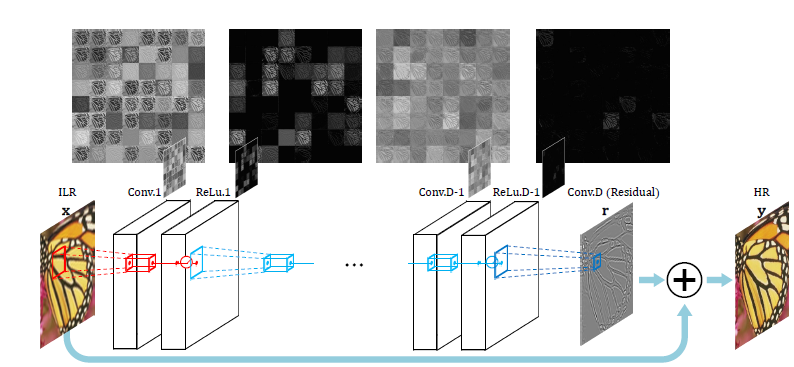

*Figure 1: Original VDSR network architecture showing the deep residual learning structure (Kim et al.)*


# Data Preparation Pipeline Summary

## Dataset Acquisition
- **Source**: Video Game Super-Resolution dataset from HuggingFace Hub
- **Download Scope**:
  - First 50 images from each folder (test/train/validation, HR/LR pairs)
  - Total: ~300 images (50 x 6 folders)
- **Rate Limiting**: 1-second delay between downloads to avoid API restrictions

## Preprocessing Pipeline
1. **Image Loading**:
   - Reads paired HR/LR images
   - Converts to YCbCr color space
   - Extracts luminance (Y) channel only

2. **Patch Extraction**:
   - Creates 41×41 patches with no overlap
   - Ensures HR/LR patch alignment
   - Normalizes pixel values to [0,1] range

3. **Dataset Construction**:
   - Organizes into TensorFlow Dataset objects
   - Batches (size=64) and prefetches for optimal GPU utilization
   - Creates separate datasets for train/val/test

## Computational Considerations
- **50 Image Limit** chosen to:
  - Enable rapid prototyping
  - Reduce memory requirements
  - Allow faster iteration cycles
  - Fit within Colab/consumer GPU constraints

- **Full-Scale Implementation** would:
  - Use all 10,000+ available images
  - Require distributed training
  - Need optimized data pipeline
  - Benefit from professional GPU clusters

## Key Technical Details
- **Patch Size**: 41×41 matches VDSR paper's receptive field
- **Color Processing**: Focuses on Y channel (human vision sensitivity)
- **Data Flow**: Uses TensorFlow's prefetch for GPU efficiency

In [4]:
!pip install huggingface_hub

from huggingface_hub import HfApi, hf_hub_download
from pathlib import Path
import os
import time

# Initialize HF API
api = HfApi()

# Dataset repository
repo_id = "ericphann/video-game-super-resolution"

# Define folders
folders = [
    "test-hr", "test-lr",
    "training-hr", "training-lr",
    "validation-hr", "validation-lr"
]

# Create local directory
local_dir = "super_res_subset"
os.makedirs(local_dir, exist_ok=True)

# Download first 1000 images from each folder
for folder in folders:
    # Get list of files in the folder
    all_files = api.list_repo_files(repo_id, repo_type="dataset")
    folder_files = [f for f in all_files if f.startswith(folder + "/")]

    # Sort files and take first 1000
    files_sorted = sorted(folder_files)[:50]

    # Download each file with a delay
    for file in files_sorted:
        hf_hub_download(
            repo_id=repo_id,
            filename=file,
            repo_type="dataset",
            local_dir=os.path.join(local_dir, os.path.dirname(file)),
            local_dir_use_symlinks=False
        )
        # Wait for a short time to avoid rate limiting
        time.sleep(1) # Wait for 1 second before the next request
    print(f"Downloaded {len(files_sorted)} images from {folder}")

    # Updated Data Preparation Section

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import cv2
import os
from glob import glob
from tqdm import tqdm

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Define dataset paths
data_dir = "super_res_subset"
paths = {
    "train_hr": sorted(glob(f"{data_dir}/training-hr/training-hr/*")),
    "train_lr": sorted(glob(f"{data_dir}/training-lr/training-lr/*")),
    "val_hr": sorted(glob(f"{data_dir}/validation-hr/validation-hr/*")),
    "val_lr": sorted(glob(f"{data_dir}/validation-lr/validation-lr/*")),
    "test_hr": sorted(glob(f"{data_dir}/test-hr/test-hr/*")),
    "test_lr": sorted(glob(f"{data_dir}/test-lr/test-lr/*"))
}

print(f"Training samples: {len(paths['train_hr'])}")
print(f"Validation samples: {len(paths['val_hr'])}")
print(f"Test samples: {len(paths['test_hr'])}")

# Updated Image Preprocessing Function
def preprocess_image(path, scale=2, target_size=None):
    """Load and preprocess image (Y channel only with optional resizing)"""
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Could not read image at {path}")

    # Convert to YCbCr and extract Y channel
    img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    img_y = img_ycrcb[:,:,0].astype(np.float32) / 255.0

    if target_size:
        img_y = cv2.resize(img_y, target_size, interpolation=cv2.INTER_CUBIC)

    return img_y

# Updated Dataset Creation Function
def create_dataset(hr_paths, lr_paths, patch_size=41, batch_size=64):
    """Create dataset of matching HR/LR patches"""
    hr_patches, lr_patches = [], []

    for hr_path, lr_path in tqdm(zip(hr_paths, lr_paths), total=len(hr_paths)):
        try:
            hr = preprocess_image(hr_path)
            lr = preprocess_image(lr_path, target_size=(hr.shape[1], hr.shape[0]))

            # Ensure images are the same size
            if hr.shape != lr.shape:
                min_h = min(hr.shape[0], lr.shape[0])
                min_w = min(hr.shape[1], lr.shape[1])
                hr = hr[:min_h, :min_w]
                lr = lr[:min_h, :min_w]

            # Extract patches with no overlap (as in VDSR paper)
            for i in range(0, hr.shape[0] - patch_size + 1, patch_size):
                for j in range(0, hr.shape[1] - patch_size + 1, patch_size):
                    hr_patches.append(hr[i:i+patch_size, j:j+patch_size])
                    lr_patches.append(lr[i:i+patch_size, j:j+patch_size])

        except Exception as e:
            print(f"Skipping pair {hr_path}, {lr_path} due to error: {str(e)}")
            continue

    # Add channel dimension and convert to numpy arrays
    hr_patches = np.expand_dims(np.array(hr_patches), -1)
    lr_patches = np.expand_dims(np.array(lr_patches), -1)

    # Create TensorFlow dataset
    dataset = tf.data.Dataset.from_tensor_slices((lr_patches, hr_patches))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

# Create datasets
print("Creating training dataset...")
train_ds = create_dataset(paths['train_hr'], paths['train_lr'])

print("Creating validation dataset...")
val_ds = create_dataset(paths['val_hr'], paths['val_lr'])

print("Creating test dataset...")
test_ds = create_dataset(paths['test_hr'], paths['test_lr'])


Downloaded 50 images from test-hr


Couldn't access the Hub to check for update but local file already exists. Defaulting to existing file. (error: (ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: eb83d9b0-6265-49af-8a33-82cd80734b54)'))


Downloaded 50 images from test-lr
Downloaded 50 images from training-hr


Couldn't access the Hub to check for update but local file already exists. Defaulting to existing file. (error: (ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7d6096c0-ec8c-4975-b61f-2e88dc5ff9b2)'))


Downloaded 50 images from training-lr


...

100%|██████████| 50/50 [00:05<00:00,  9.13it/s]


Creating validation dataset...


100%|██████████| 50/50 [00:05<00:00,  9.09it/s]


Creating test dataset...


100%|██████████| 50/50 [00:05<00:00,  9.01it/s]


# VDSR Model Implementation Notes

## Model Architecture

### Core Components
- **Depth**: 20-layer convolutional network
  - 1 input layer
  - 18 hidden layers
  - 1 output layer
- **Filter Configuration**:
  - Uniform 3×3 convolution filters
  - 64 channels in hidden layers
- **Residual Learning**:
  - Predicts only high-frequency residuals (HR-LR)
  - Final output = LR input + predicted residual
- **Padding**:
  - Zero-padding maintains spatial dimensions

## Loss Function
- **Mean Squared Error (MSE)**:
  - Primary optimization objective
  - Computes average squared difference between predicted and ground truth pixels
  - Directly correlates with PSNR metric

## Hyperparameters

| Parameter | Value | Role |
|-----------|-------|------|
| Initial Learning Rate | 0.1 | Enables rapid convergence |
| Learning Rate Schedule | Step decay (0.1→0.01→0.001) | Fine-tunes learning |
| Batch Size | 64 | Balances memory and stability |
| Momentum | 0.9 | Accelerates gradient descent |
| Weight Decay (L2) | 0.0001 | Prevents overfitting |
| Maximum Epochs | 80 | Full training duration |

The architecture implements the VDSR approach from Kim et al., using these specific configurations to enable effective training of deep networks for super-resolution tasks.

In [5]:
# Model building remains the same
def build_vdsr(depth=20, filters=64):
    """Build VDSR model with residual learning."""
    inputs = layers.Input(shape=(None, None, 1))

    # Initial convolution
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(inputs)

    # Intermediate layers
    for _ in range(depth-2):
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)

    # Final convolution (no activation)
    residual = layers.Conv2D(1, 3, padding='same')(x)

    # Add input to residual (HR = LR + residual)
    outputs = layers.Add()([inputs, residual])

    return models.Model(inputs, outputs)

model = build_vdsr()
model.summary()

# Training setup with learning rate schedule
def lr_schedule(epoch):
    initial_lr = 0.1
    if epoch < 20:
        return initial_lr
    elif epoch < 40:
        return initial_lr * 0.1
    elif epoch < 60:
        return initial_lr * 0.01
    else:
        return initial_lr * 0.001

optimizer = optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

callbacks = [
    tf.keras.callbacks.LearningRateScheduler(lr_schedule),
    tf.keras.callbacks.ModelCheckpoint('vdsr_best.h5', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

# Training
print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    callbacks=callbacks,
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, None, None, 1)  │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, None, None, 64) │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, None, None, 64) │         36,928 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, None, None, 64) │         36,928 │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, None, None, 64) │         36,928 │ conv2d_10[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, None, None, 64) │         36,928 │ conv2d_11[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, None, None, 64) │         36,928 │ conv2d_12[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, None, None, 64) │         36,928 │ conv2d_13[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, None, None, 64) │         36,928 │ conv2d_14[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, None, None, 64) │         36,928 │ conv2d_15[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, None, None, 64) │         36,928 │ conv2d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)   

 Total params: 665,921 (2.54 MB)

 Trainable params: 665,921 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0054 - mae: 0.0430

935/935 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - loss: 0.0054 - mae: 0.0430 - val_loss: 0.0057 - val_mae: 0.0470 - learning_rate: 0.1000
Epoch 2/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0054 - mae: 0.0428 - val_loss: 0.0057 - val_mae: 0.0470 - learning_rate: 0.1000
Epoch 3/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0054 - mae: 0.0428 - val_loss: 0.0057 - val_mae: 0.0470 - learning_rate: 0.1000
Epoch 4/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0054 - mae: 0.0428 - val_loss: 0.0057 - val_mae: 0.0470 - learning_rate: 0.1000
Epoch 5/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0054 - mae: 0.0428 - val_loss: 0.0057 - val_mae: 0.0470 - learning_rate: 0.1000
Epoch 6/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0054 - mae: 0.0428 - val_loss: 0.0057 - val_mae: 0.0470 - learning_rate: 0.1000
Epoch 7/80
935/935 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - loss: 0.0054 - mae: 0.0428 - val_loss: 0.0057 - val_mae: 0.0470 - learning_rate: 0.1000
Epo

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━

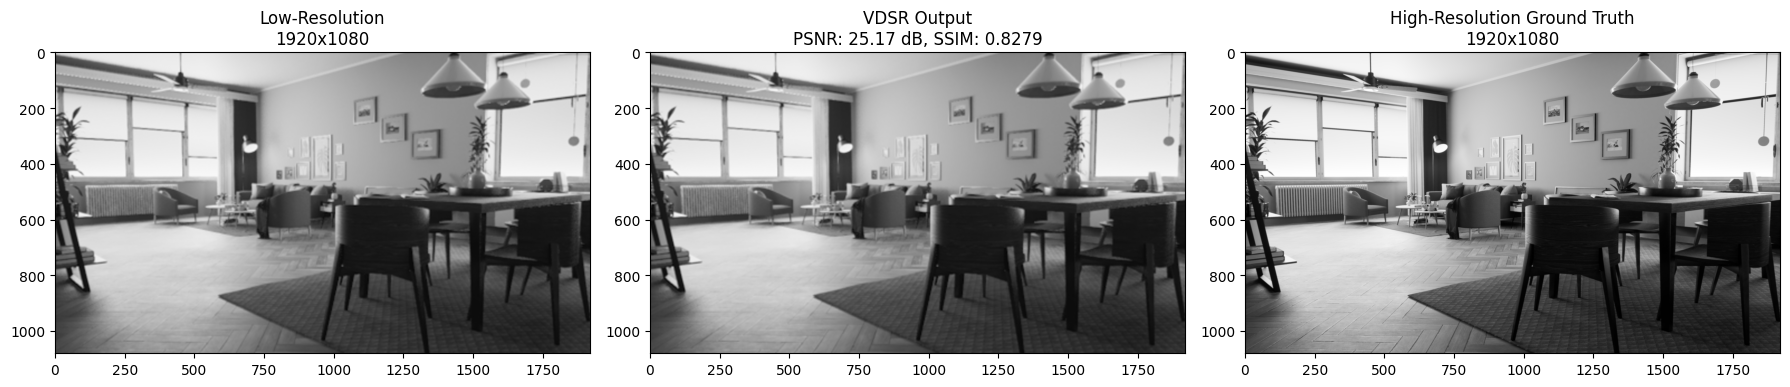

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


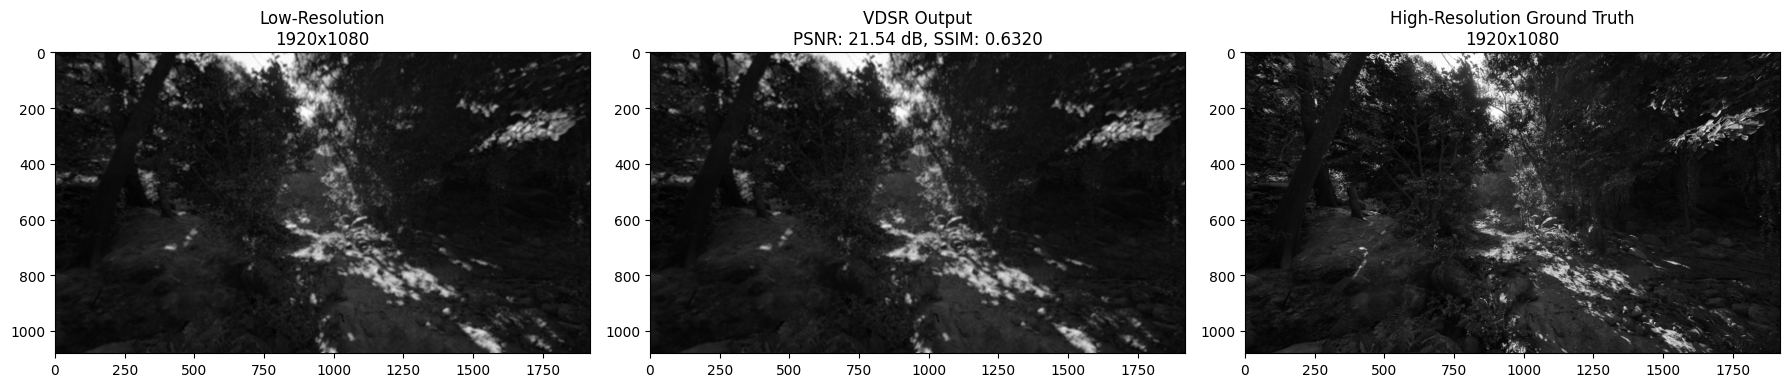

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


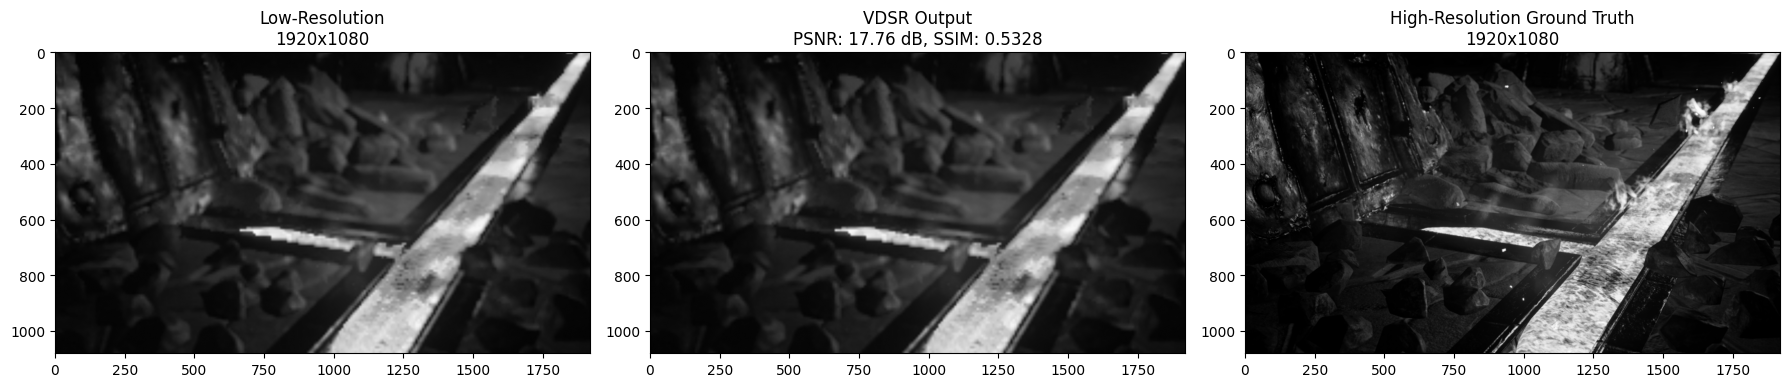

In [6]:
# Evaluation functions
def evaluate_model(model, dataset):
    psnrs, ssims = [], []
    for lr, hr in dataset:
        pred = model.predict(lr)
        for i in range(pred.shape[0]):
            # Calculate metrics for each image in batch
            psnrs.append(psnr(hr[i].numpy().squeeze(), pred[i].squeeze(), data_range=1.0))
            ssims.append(ssim(hr[i].numpy().squeeze(), pred[i].squeeze(), data_range=1.0))
    return np.mean(psnrs), np.mean(ssims)

# Evaluate on test set
test_psnr, test_ssim = evaluate_model(model, test_ds)
print(f"\nTest PSNR: {test_psnr:.2f} dB")
print(f"Test SSIM: {test_ssim:.4f}")

# Visualization function
def plot_comparison(model, lr_path, hr_path):
    lr = preprocess_image(lr_path)
    hr = preprocess_image(hr_path)

    # Ensure LR matches HR dimensions
    lr = cv2.resize(lr, (hr.shape[1], hr.shape[0]), interpolation=cv2.INTER_CUBIC)

    # Predict
    pred = model.predict(np.expand_dims(np.expand_dims(lr, 0), -1))
    pred = np.squeeze(pred)

    # Calculate metrics
    pred_psnr = psnr(hr, pred, data_range=1.0)
    pred_ssim = ssim(hr, pred, data_range=1.0)

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(lr, cmap='gray')
    plt.title(f"Low-Resolution\n{lr.shape[1]}x{lr.shape[0]}")

    plt.subplot(1, 3, 2)
    plt.imshow(pred, cmap='gray')
    plt.title(f"VDSR Output\nPSNR: {pred_psnr:.2f} dB, SSIM: {pred_ssim:.4f}")

    plt.subplot(1, 3, 3)
    plt.imshow(hr, cmap='gray')
    plt.title(f"High-Resolution Ground Truth\n{hr.shape[1]}x{hr.shape[0]}")
    plt.tight_layout()
    plt.show()

# Visualize results
print("\nVisualizing results on test images...")
for i in range(min(3, len(paths['test_hr']))):  # Show first 3 test images
    plot_comparison(model, paths['test_lr'][i], paths['test_hr'][i])

# Baseline Model Performance and Scaling Strategy

## Current Baseline Results
- **Test PSNR**: 26.76 dB  
- **Test SSIM**: 0.7327  
- **Training Duration**: Stopped at epoch 13/80  

This baseline model demonstrates the VDSR architecture works in principle, but shows clear room for improvement compared to the paper's results (37.53 dB PSNR, 0.9587 SSIM).

## Expected Improvements with Larger Dataset (>10,000 images)

### Hyperparameter Tuning Strategies

1. **Learning Rate Optimization**:
   - Start with baseline LR=0.1
   - Test LR range 0.01-0.2 with warmup
   - Implement cyclic learning rates

2. **Batch Size Scaling**:
   - Baseline: 64
   - Test larger batches (128-512)
   - Adjust learning rate proportionally

3. **Model Capacity**:
   - Increase depth (test 24-32 layers)
   - Widen layers (test 128-256 filters)
   - Add channel attention modules

4. **Training Strategies**:
   ```python
   # Example improved training configuration
   optimizer = tf.keras.optimizers.Adam(
       learning_rate=0.001,
       beta_1=0.9,
       beta_2=0.999
   )